# Feature Importance Analysis

**Research questions addressed:**  
> RQ2: Which eBPF-derived metrics contribute most to detection?  

This notebook is intentionally bounded and diagnostic:
- It uses the **saved Split 4 headline artifacts** from Notebook 01.
- Permutation importance and SHAP run on sampled realistic-test subsets to keep the analysis stable.
- The feature-group masking section is a **diagnostic masking study**, not a causal retraining ablation proof.


In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *
from ml.notebooks.modeling_pipeline import (
    load_model_pack,
    prepare_split,
    align_to_features,
    binary_metrics,
)

PERMUTATION_SAMPLE_N = 3000
PERMUTATION_REPEATS = 3
SHAP_SAMPLE_N = 512
SHAP_BACKGROUND_N = 64
ABLATION_SAMPLE_N = 3000

FI_DIR = REPORTS_DIR / 'feature_importance' / f'seed{RANDOM_SEED}'
FI_DIR.mkdir(parents=True, exist_ok=True)
print('[*] Output:', FI_DIR)


[*] Output: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed42


## Setup: Load saved headline artifacts and bounded realistic test matrices

Permutation and SHAP operate on fixed-size sampled subsets of the Split 4 realistic holdout. The masking study uses the full realistic holdout because it only requires a few extra forward passes and is cheap enough to run without retraining.


In [2]:
PACKS = {
    'baseline': load_model_pack('baseline', artifact='headline', seed=RANDOM_SEED),
    'ebpf': load_model_pack('ebpf', artifact='headline', seed=RANDOM_SEED),
}

SPLIT4 = {'baseline': SPLITS_4_BASELINE, 'ebpf': SPLITS_4_EBPF}

PERMUTATION_SAMPLE_N = 5000
PERMUTATION_REPEATS = 5
SHAP_SAMPLE_N = 384
SHAP_BACKGROUND_N = 64

def stratified_sample(df: pd.DataFrame, sample_n: int, seed: int = RANDOM_SEED) -> pd.DataFrame:
    if len(df) <= sample_n:
        return df.copy()
    rng = np.random.default_rng(seed)
    pos_idx = df.index[df['is_attack'] == 1].to_numpy()
    neg_idx = df.index[df['is_attack'] == 0].to_numpy()
    pos_n = int(round(sample_n * len(pos_idx) / len(df)))
    pos_n = min(max(pos_n, 1), len(pos_idx))
    neg_n = min(sample_n - pos_n, len(neg_idx))
    if neg_n <= 0:
        neg_n = min(1, len(neg_idx))
    chosen = np.concatenate([
        rng.choice(pos_idx, size=pos_n, replace=False),
        rng.choice(neg_idx, size=neg_n, replace=False),
    ])
    rng.shuffle(chosen)
    return df.loc[chosen].copy()

def prepare_xy(df: pd.DataFrame, feature_list):
    prep = prepare_split(df, feature_list=feature_list)
    return align_to_features(prep.X, feature_list), prep.y

DATA = {}
for fs in ['baseline', 'ebpf']:
    feat = PACKS[fs]['features']
    te_real_df = pd.read_parquet(SPLIT4[fs] / 'test_realistic.parquet')
    perm_df = stratified_sample(te_real_df, PERMUTATION_SAMPLE_N, seed=RANDOM_SEED)
    shap_df = stratified_sample(te_real_df, SHAP_SAMPLE_N, seed=RANDOM_SEED + 1)

    Xperm, yperm = prepare_xy(perm_df, feat)
    Xablate, yablate = prepare_xy(te_real_df, feat)
    Xshap, yshap = prepare_xy(shap_df, feat)

    DATA[fs] = {
        'Xperm': Xperm, 'yperm': yperm,
        'Xablate': Xablate, 'yablate': yablate,
        'Xshap': Xshap, 'yshap': yshap,
        'realistic_rows': int(len(te_real_df)),
        'features': feat,
    }
    del te_real_df, perm_df, shap_df
    print(
        f"[*] {fs}: selected={PACKS[fs]['selected_model_name']} "
        f"features={len(feat)} realistic_rows={DATA[fs]['realistic_rows']:,} "
        f"perm_sample={len(DATA[fs]['Xperm']):,} shap_sample={len(DATA[fs]['Xshap']):,} "
        f"ablation_rows={len(DATA[fs]['Xablate']):,}"
    )


[*] baseline: selected=hgb_balanced features=10 realistic_rows=546,207 perm_sample=5,000 shap_sample=384 ablation_rows=546,207
[*] ebpf: selected=hgb_balanced features=17 realistic_rows=546,207 perm_sample=5,000 shap_sample=384 ablation_rows=546,207


## Method 1: Permutation importance on a stratified sampled realistic test set

This is a bounded ranking diagnostic. It measures how much a feature hurts sampled realistic-set performance when permuted, but it does not prove that retraining without that feature would have the same effect.


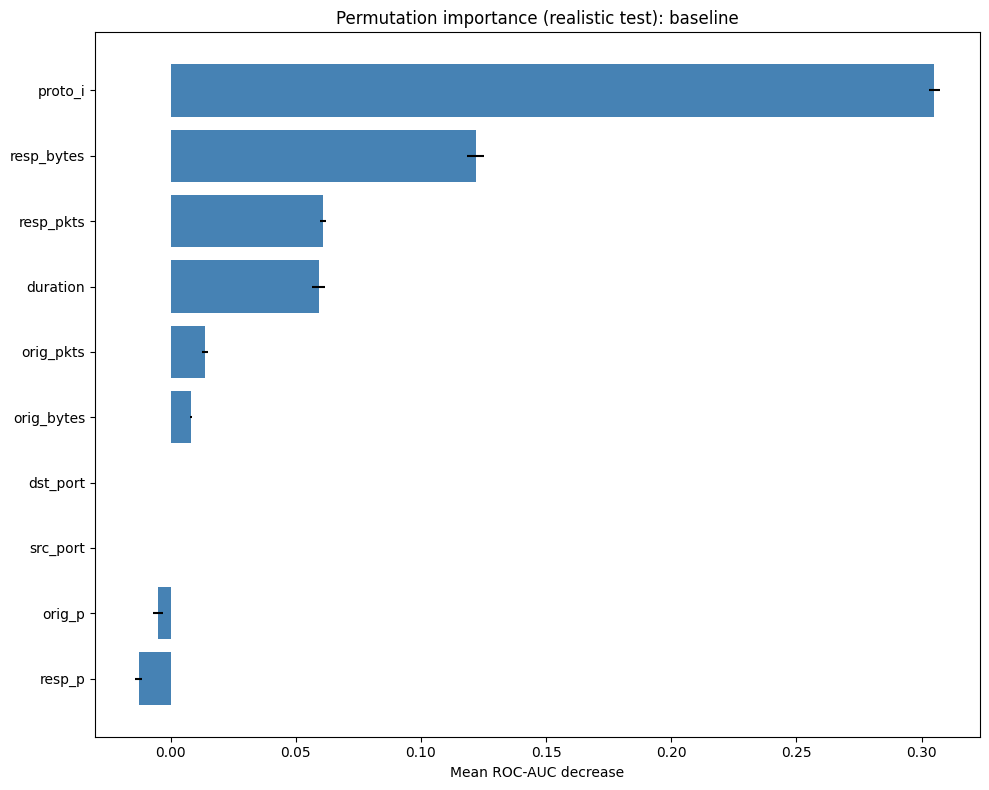

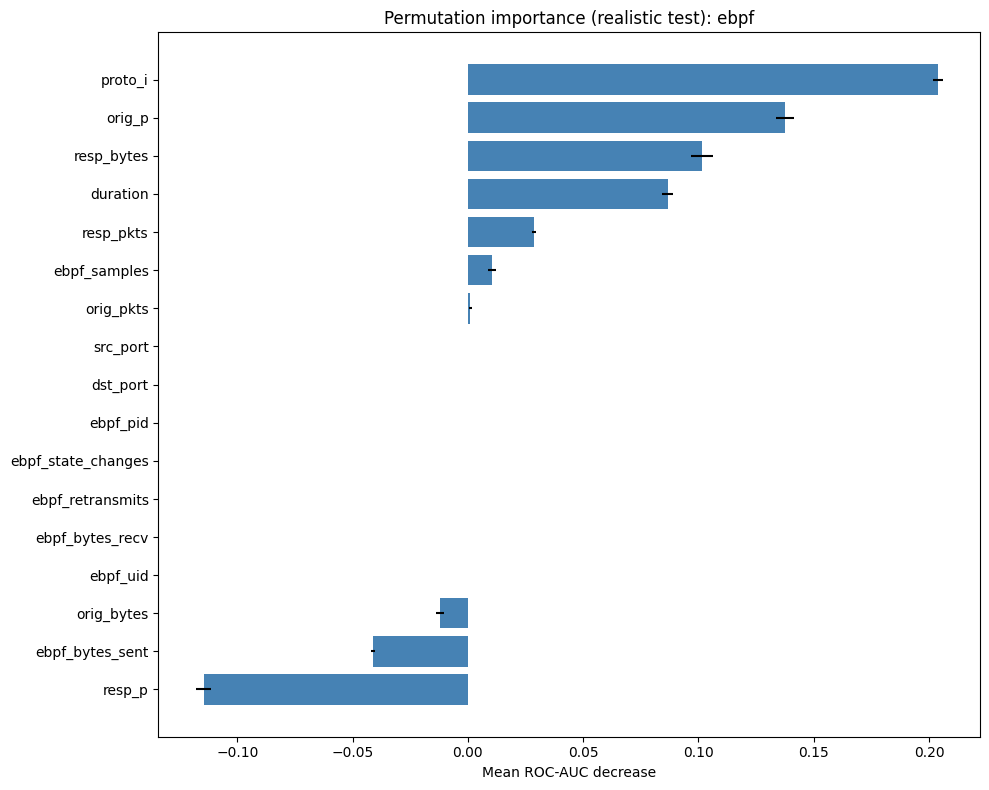

In [3]:
def run_permutation(fs_name: str, sample_n: int = PERMUTATION_SAMPLE_N, n_repeats: int = PERMUTATION_REPEATS):
    pack = PACKS[fs_name]
    model = pack['model']
    d = DATA[fs_name]

    X = d['Xperm']
    y = d['yperm']

    pi = permutation_importance(
        model,
        X,
        y,
        scoring='roc_auc',
        n_repeats=n_repeats,
        random_state=RANDOM_SEED,
        n_jobs=1,
    )
    imp = pd.DataFrame({
        'feature': d['features'],
        'importance_mean': pi.importances_mean,
        'importance_std': pi.importances_std,
    }).sort_values('importance_mean', ascending=False)

    imp.to_csv(FI_DIR / f'permutation_{fs_name}.csv', index=False)

    top = imp.head(25).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'], color='steelblue')
    ax.set_title(f'Permutation importance (realistic test): {fs_name}')
    ax.set_xlabel('Mean ROC-AUC decrease')
    plt.tight_layout()
    plt.savefig(FI_DIR / f'permutation_{fs_name}.png', dpi=150)
    plt.show()

    return imp

IMP_BASE = run_permutation('baseline')
IMP_EBPF = run_permutation('ebpf')


## Method 2: Diagnostic feature-group masking on the full realistic test set

This section keeps the trained headline model fixed and replaces masked feature groups with their training-time median values before inference. It is more informative than zero-masking, but it is still a **diagnostic masking study** rather than a causal ablation proof.


              variant        model  n_features  roc_auc_realistic  pr_auc_realistic  f1_realistic  recall_realistic  precision_realistic  delta_roc_auc_realistic_vs_all  delta_pr_auc_realistic_vs_all  delta_f1_realistic_vs_all  delta_recall_realistic_vs_all  delta_precision_realistic_vs_all
         all_features hgb_balanced          17             0.7115            0.7155        0.5144            0.3675               0.8572                          0.0000                         0.0000                     0.0000                         0.0000                            0.0000
zeek_only_masked_view hgb_balanced          10             0.7443            0.7449        0.5064            0.3672               0.8156                          0.0328                         0.0294                    -0.0080                        -0.0002                           -0.0416
ebpf_only_masked_view hgb_balanced           7             0.5390            0.4977        0.0000            0.0000         

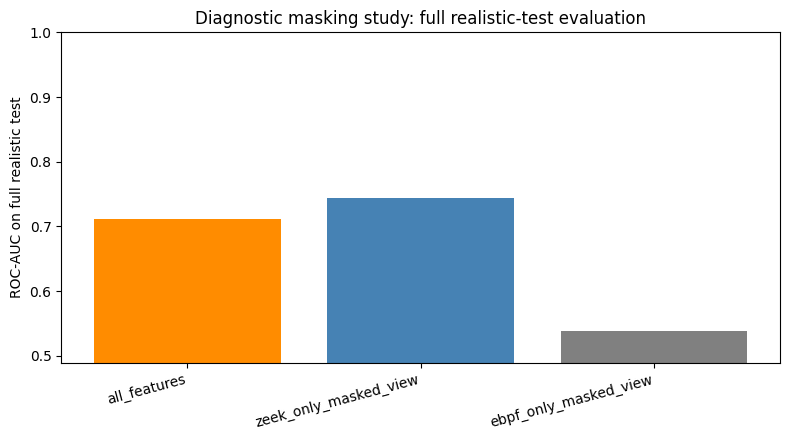

In [4]:
EBPF_HINTS = ('ebpf', 'bpf', 'pid', 'ppid', 'uid', 'gid', 'comm', 'exe', 'cmd', 'sock', 'sk_', 'tcp_', 'udp_', 'netns', 'inode', 'tgid')

fs = 'ebpf'
d = DATA[fs]
pack = PACKS[fs]

feat_all = d['features']
feat_zeek = [f for f in feat_all if not any(h in f.lower() for h in EBPF_HINTS)]
feat_ebpf_only = [f for f in feat_all if any(h in f.lower() for h in EBPF_HINTS)]

X_base = d['Xablate'].copy()
y_base = d['yablate']
score_base = pack['model'].predict_proba(X_base)[:, 1] if hasattr(pack['model'], 'predict_proba') else pack['model'].decision_function(X_base)
if np.ndim(score_base) != 1:
    score_base = score_base[:, 1]
pred_base = (score_base >= pack.get('threshold', 0.5)).astype(int)
base_metrics = binary_metrics(y_base, pred_base, score_base)

median_fill = pd.Series(0.0, index=feat_all)
if hasattr(pack['model'], 'named_steps') and 'impute' in pack['model'].named_steps:
    median_fill = pd.Series(pack['model'].named_steps['impute'].statistics_, index=feat_all)

rows = [{
    'variant': 'all_features',
    'model': pack['selected_model_name'],
    'n_features': len(feat_all),
    'roc_auc_realistic': base_metrics['roc_auc'],
    'pr_auc_realistic': base_metrics['pr_auc'],
    'f1_realistic': base_metrics['f1'],
    'recall_realistic': base_metrics['recall'],
    'precision_realistic': base_metrics['precision'],
}]

for name, feats in [('zeek_only_masked_view', feat_zeek), ('ebpf_only_masked_view', feat_ebpf_only)]:
    if not feats:
        continue
    X_masked = X_base.copy()
    drop_cols = [c for c in feat_all if c not in feats]
    for col in drop_cols:
        X_masked.loc[:, col] = median_fill[col]
    score = pack['model'].predict_proba(X_masked)[:, 1] if hasattr(pack['model'], 'predict_proba') else pack['model'].decision_function(X_masked)
    if np.ndim(score) != 1:
        score = score[:, 1]
    pred = (score >= pack.get('threshold', 0.5)).astype(int)
    metrics = binary_metrics(y_base, pred, score)
    rows.append({
        'variant': name,
        'model': pack['selected_model_name'],
        'n_features': len(feats),
        'roc_auc_realistic': metrics['roc_auc'],
        'pr_auc_realistic': metrics['pr_auc'],
        'f1_realistic': metrics['f1'],
        'recall_realistic': metrics['recall'],
        'precision_realistic': metrics['precision'],
    })

ab_df = pd.DataFrame(rows)
baseline_row = ab_df.loc[ab_df['variant'] == 'all_features'].iloc[0]
for metric in ['roc_auc_realistic', 'pr_auc_realistic', 'f1_realistic', 'recall_realistic', 'precision_realistic']:
    ab_df[f'delta_{metric}_vs_all'] = ab_df[metric] - baseline_row[metric]
print(ab_df.to_string(index=False, float_format='{:.4f}'.format))
ab_df.to_csv(FI_DIR / 'ebpf_ablation_realistic.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = ab_df.set_index('variant').loc[['all_features'] + [v for v in ab_df['variant'] if v != 'all_features']].reset_index()
ax.bar(plot_df['variant'], plot_df['roc_auc_realistic'], color=['darkorange', 'steelblue', 'grey'][:len(plot_df)])
ax.set_ylim(max(0, plot_df['roc_auc_realistic'].min() - 0.05), 1.0)
ax.set_ylabel('ROC-AUC on full realistic test')
ax.set_title('Diagnostic masking study: full realistic-test evaluation')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FI_DIR / 'ebpf_ablation_realistic.png', dpi=150)
plt.show()


## Method 3: SHAP on a bounded sampled realistic test set

SHAP is run only on a small fixed subset to avoid kernel instability. The result is an explanatory ranking of model reliance on that sampled subset, not a claim of causal necessity.


[*] Computing SHAP values for baseline (384 samples)...
  Top 5 SHAP features (baseline): ['proto_i', 'resp_bytes', 'resp_p', 'resp_pkts', 'duration']


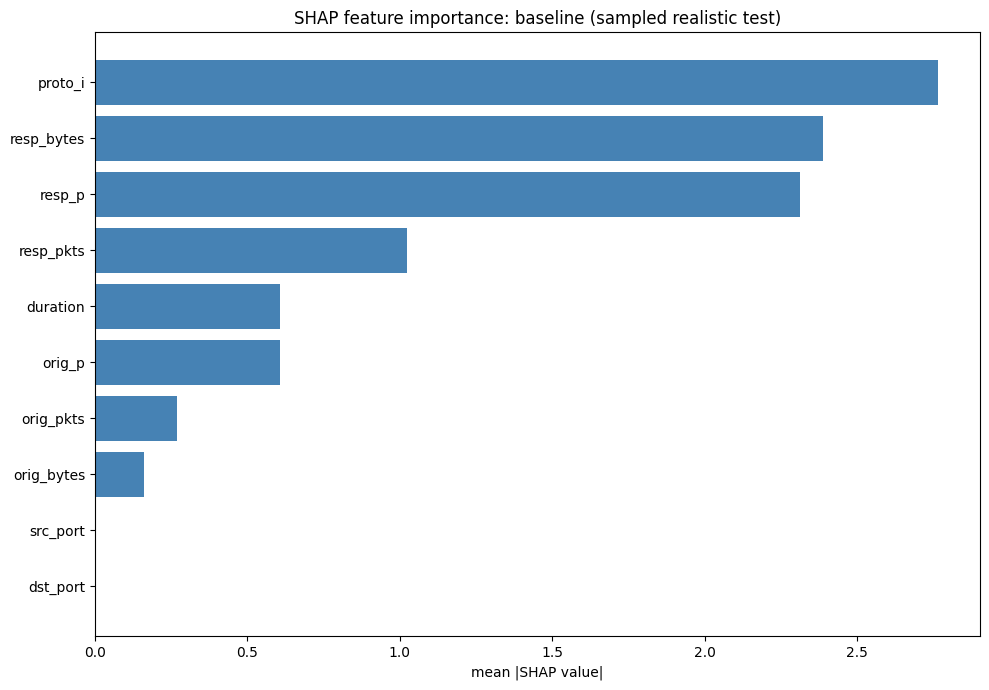

  Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed42/shap_bar_baseline.png
[*] Computing SHAP values for ebpf (384 samples)...
  Top 5 SHAP features (ebpf): ['resp_p', 'orig_p', 'resp_bytes', 'proto_i', 'ebpf_samples']


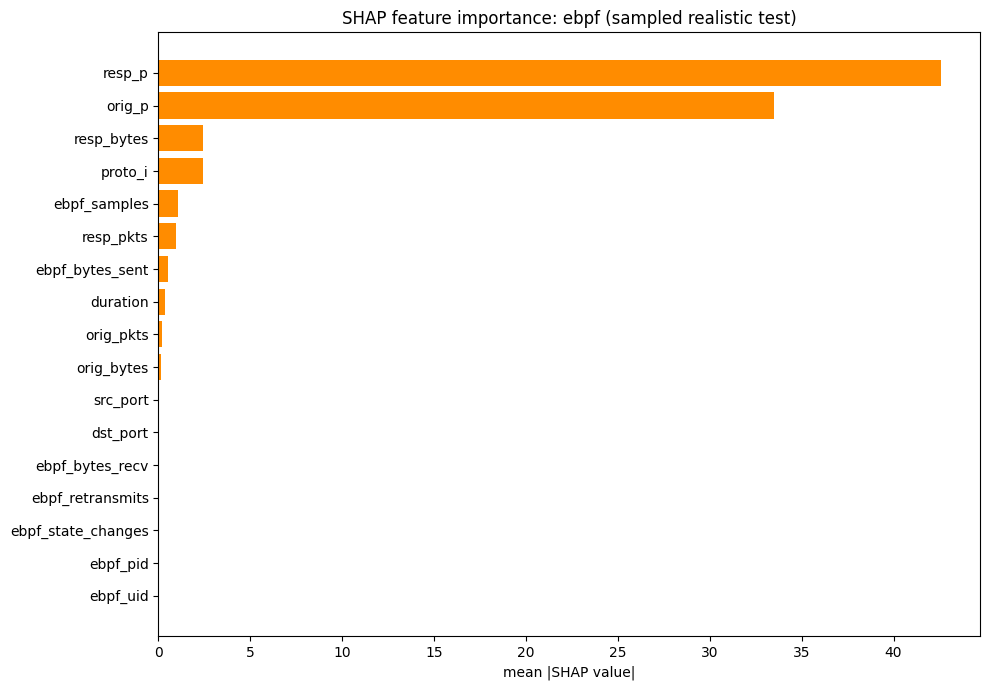

  Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed42/shap_bar_ebpf.png

[*] eBPF feature consensus ranking
           feature  importance_mean  importance_std  permutation_rank  shap_rank  mean_rank
      ebpf_samples           0.0105          0.0018                 1          1     1.0000
   ebpf_bytes_recv           0.0000          0.0000                 5          3     4.0000
  ebpf_retransmits           0.0000          0.0000                 4          4     4.0000
          ebpf_pid           0.0000          0.0000                 2          6     4.0000
ebpf_state_changes           0.0000          0.0000                 3          5     4.0000
   ebpf_bytes_sent          -0.0410          0.0009                 7          2     4.5000
          ebpf_uid           0.0000          0.0000                 6          7     6.5000

[+] SHAP analysis complete.


In [5]:
try:
    import shap
except Exception as exc:
    shap = None
    print(f'[!] SHAP unavailable, skipping SHAP analysis: {exc}')

def prepare_shap_inputs(model, X_df: pd.DataFrame):
    if hasattr(model, 'named_steps') and 'clf' in model.named_steps:
        clf = model.named_steps['clf']
        if len(model.steps) > 1:
            X_proc = model[:-1].transform(X_df)
        else:
            X_proc = X_df.to_numpy()
        return clf, np.asarray(X_proc), list(X_df.columns)
    return model, X_df.to_numpy(), list(X_df.columns)

if shap is not None:
    for fs_name in ['baseline', 'ebpf']:
        pack = PACKS[fs_name]
        d = DATA[fs_name]
        X_shap = d['Xshap']
        print(f'[*] Computing SHAP values for {fs_name} ({len(X_shap)} samples)...')

        expl_model, X_proc, feature_names = prepare_shap_inputs(pack['model'], X_shap)
        selected = pack.get('selected_model_name', '')

        if any(tag in selected for tag in ('hgb', 'rf', 'et')) or 'forest' in str(type(expl_model)).lower() or 'gradient' in str(type(expl_model)).lower():
            explainer = shap.TreeExplainer(expl_model)
            shap_values = explainer.shap_values(X_proc)
        elif 'logreg' in selected or 'logistic' in str(type(expl_model)).lower():
            background = X_proc[: min(SHAP_BACKGROUND_N, len(X_proc))]
            explainer = shap.LinearExplainer(expl_model, background)
            shap_values = explainer.shap_values(X_proc)
        else:
            print(f'  [!] Unsupported model for bounded SHAP run: {selected or type(expl_model).__name__}')
            continue

        if isinstance(shap_values, list):
            shap_values = shap_values[-1]

        mean_shap = np.abs(shap_values).mean(axis=0)
        shap_df = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_shap}).sort_values('mean_abs_shap', ascending=False)
        shap_df.head(20).to_csv(FI_DIR / f'shap_top20_{fs_name}.csv', index=False)
        print(f'  Top 5 SHAP features ({fs_name}): {shap_df.head(5).feature.tolist()}')

        top = shap_df.head(20).iloc[::-1]
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.barh(top['feature'], top['mean_abs_shap'], color='darkorange' if fs_name == 'ebpf' else 'steelblue')
        ax.set_title(f'SHAP feature importance: {fs_name} (sampled realistic test)')
        ax.set_xlabel('mean |SHAP value|')
        plt.tight_layout()
        out = FI_DIR / f'shap_bar_{fs_name}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Saved: {out}')

    if (FI_DIR / 'permutation_ebpf.csv').exists() and (FI_DIR / 'shap_top20_ebpf.csv').exists():
        perm = pd.read_csv(FI_DIR / 'permutation_ebpf.csv')
        perm = perm[perm['feature'].str.startswith('ebpf_')].copy().reset_index(drop=True)
        perm['permutation_rank'] = np.arange(1, len(perm) + 1)
        shap_top = pd.read_csv(FI_DIR / 'shap_top20_ebpf.csv')
        shap_top = shap_top[shap_top['feature'].str.startswith('ebpf_')].copy().reset_index(drop=True)
        shap_top['shap_rank'] = np.arange(1, len(shap_top) + 1)
        consensus = perm.merge(shap_top[['feature', 'shap_rank']], on='feature', how='outer')
        max_rank = max(len(perm), len(shap_top), 1) + 1
        consensus['permutation_rank'] = consensus['permutation_rank'].fillna(max_rank)
        consensus['shap_rank'] = consensus['shap_rank'].fillna(max_rank)
        consensus['mean_rank'] = consensus[['permutation_rank', 'shap_rank']].mean(axis=1)
        consensus = consensus.sort_values('mean_rank').reset_index(drop=True)
        consensus.to_csv(FI_DIR / 'ebpf_feature_consensus.csv', index=False)
        print('\n[*] eBPF feature consensus ranking')
        print(consensus.to_string(index=False, float_format='{:.4f}'.format))

    print('\n[+] SHAP analysis complete.')
